### Step 1:-  Import the  Required Libraries

In [1]:
import pandas as pd
from sklearn.linear_model import LogisticRegression  # Model used for classification
from sklearn.model_selection import train_test_split  # Split data into training and test sets
import matplotlib.pyplot as plt
import seaborn as sns  # Used for visualization
from sklearn.pipeline import Pipeline  # Create the machine learning pipeline
from sklearn.preprocessing import StandardScaler  # Standardize the numerical features
import time  # Measure training and testing time
from sklearn.metrics import accuracy_score  # Calculate prediction accuracy

### Step 2:- Load the Iris data to the pandas data frame

In [2]:
# Use header as "none" because iris original data file has no column names 
iris_data = pd.read_csv("data/iris/iris.data", header=None)

In [3]:
# Print the first 5 rows of the data
print(iris_data.head())

     0    1    2    3            4
0  5.1  3.5  1.4  0.2  Iris-setosa
1  4.9  3.0  1.4  0.2  Iris-setosa
2  4.7  3.2  1.3  0.2  Iris-setosa
3  4.6  3.1  1.5  0.2  Iris-setosa
4  5.0  3.6  1.4  0.2  Iris-setosa


In [4]:
#Because there are no column names so this step adds the header to iris_data that is loaded
iris_data.columns=[
    "sepal_length",
    "sepal_width",
    "petal_length",
    "petal_width",
    "class"
]

### Step 3:- Sanity check of the data

In [5]:
#print first 5 rows of the data
iris_data.head()

,sepal_length,sepal_width,petal_length,petal_width,class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [6]:
#check the shape of the dataset
iris_data.shape

(150, 5)

In [7]:
#check the datatypes of each column
iris_data.dtypes

sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
class               str
dtype: object

In [8]:
#check the total number missing values in each colum
iris_data.isnull().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
class           0
dtype: int64

In [9]:
#check the class distribution
iris_data["class"].value_counts()

class
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

In [10]:
#check the smmary statistics(count,mean,standard deviation,min,quartiles and max) of the numeric columns
iris_data.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


### Step 4 :- Seperate the features and target

In [11]:
#Seperate input features as X and target class as y

X = iris_data[["sepal_length","sepal_width","petal_length","petal_width"]]
y = iris_data["class"]

In [12]:
X.head()

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [13]:
y.head()

0    Iris-setosa
1    Iris-setosa
2    Iris-setosa
3    Iris-setosa
4    Iris-setosa
Name: class, dtype: str

### Step5:- Split the Data into Training and Test set 

In [14]:
# 1. Split the features and target into training and test sets.
# 2. Keep 80% of the data for training and 20% for testing.
# 3. Preserve the class proportions in both sets by using stratify =y 

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y 
)

In [15]:
#check the shape of the train and test data
print(X_train.shape,y_train.shape,X_test.shape,y_test.shape)

(120, 4) (120,) (30, 4) (30,)


In [16]:
print("Training data class distribution")
print(y_train.value_counts())
print("Test data class distribution")
print(y_test.value_counts())

Training data class distribution
class
Iris-setosa        40
Iris-virginica     40
Iris-versicolor    40
Name: count, dtype: int64
Test data class distribution
class
Iris-setosa        10
Iris-virginica     10
Iris-versicolor    10
Name: count, dtype: int64


### Step 6:- Visualize the Training Data

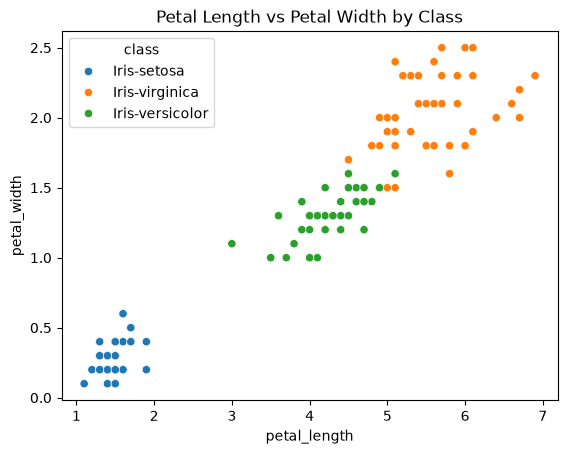

In [17]:
# Combining training features and target for plotting
train_data = X_train.copy()
train_data["class"] = y_train

sns.scatterplot(
    data=train_data,
    x="petal_length",
    y="petal_width",
    hue="class"
)

plt.title("Petal Length vs Petal Width by Class")
plt.show()

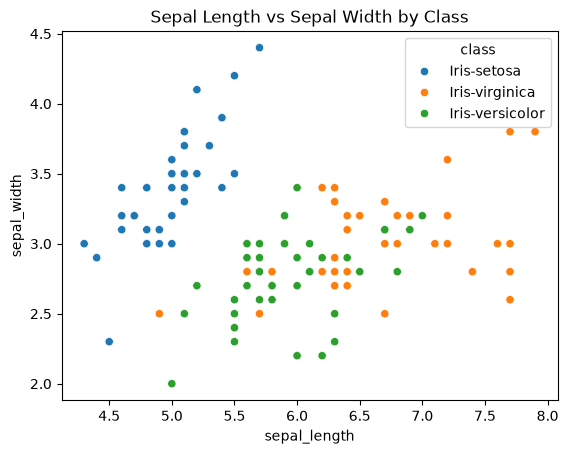

In [18]:
sns.scatterplot(
    data=train_data,
    x="sepal_length",
    y="sepal_width",
    hue="class"
)

plt.title("Sepal Length vs Sepal Width by Class")
plt.show()

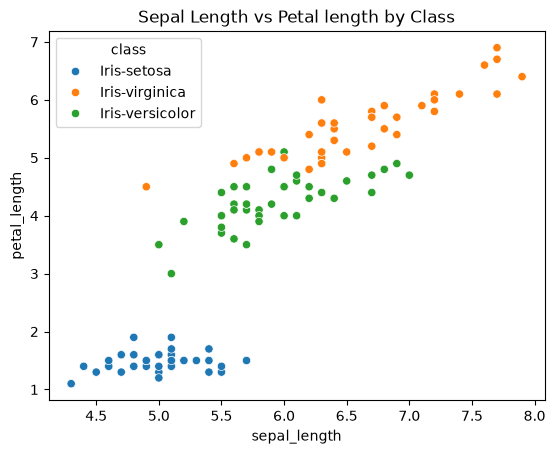

In [19]:
sns.scatterplot(
    data=train_data,
    x="sepal_length",
    y="petal_length",
    hue="class"
)

plt.title("Sepal Length vs Petal length by Class")
plt.show()

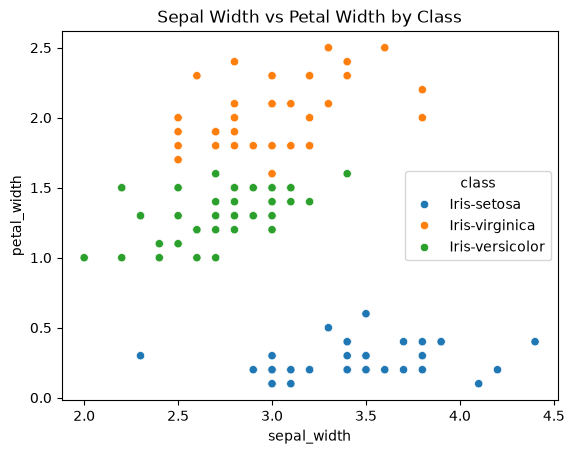

In [20]:
sns.scatterplot(
    data=train_data,
    x="sepal_width",
    y="petal_width",
    hue="class"
)

plt.title("Sepal Width vs Petal Width by Class")
plt.show()

### Step 7:- Create the scikit-learn Pipeline

In [21]:
# Create a pipeline that first standardizes the input features
# and then uese Logistic Regression for classification
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression())
])

### Step 8:- Train the Pipeline and Measure Training Time

In [22]:

# Start the timer before training
start_time = time.perf_counter()

# Fit the pipeline using the training features and labels
pipeline.fit(X_train, y_train)

# Stop the timer after training
end_time = time.perf_counter()

# Calculate the total training time
training_time = end_time - start_time

print(f"Training Time: {training_time:.6f} seconds")

Training Time: 0.016958 seconds


### Step 9:-  Predict on the Test Data and Measure Testing Time

In [26]:
# start the timer before prediction / testing starts
start_time = time.perf_counter()  

# Predict the test labels using the trained pipeline
y_pred = pipeline.predict(X_test)

# Stopping the timer after prediction
end_time = time.perf_counter() 

# Calculating the total testing time
testing_time = end_time - start_time 

print(f"Testing Time: {testing_time:.6f} seconds")

Testing Time: 0.002442 seconds


### Step 10: Evaluate Test Accuracy.

In [24]:
# Calculate prediction accuracy by comparing the actual and predicted labels
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy:- {accuracy * 100:.2f}%")

Test Accuracy:- 93.33%
